<a href="https://colab.research.google.com/github/prachitshukla/DLFA-Kaggle/blob/development/M6_Mini_Hackathon_Caltech_256_image_classification_ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Objective:
To classify images in the Caltech-256 dataset, which is an improvement over Caltech-101 dataset using a Convolutional Neural Network.

### Problem Statement
To build and implement a Convolutional Neural Network model to classify images in the Caltech-256 dataset.

At the end of this competition, you will be able to:

* Load and extract features of images available in the Caltech-256 dataset using ImageDataGenerator

* Build convolutional neural networks using either Keras or PyTorch deep learning libraries

* Use the pre-trained models using either Keras or PyTorch deep learning libraries

### Description:
Caltech-256 is an object recognition dataset containing approximately 30,000 real-world images, of different sizes, spanning 256 classes (256 object classes and an additional clutter class). Each class is represented by at least 80 images. The dataset is a superset of the Caltech-101 dataset.

Here is a handy link to Kaggle's competition documentation (https://www.kaggle.com/docs/competitions), which includes, among other things, instructions on submitting predictions (https://www.kaggle.com/docs/competitions#making-a-submission).

### Instructions for downloading train and test data are as follows:

### 1. Create an API key in Kaggle.

To do this, go to the competition site on Kaggle at (https://www.kaggle.com/t/a4a5979690d44302a54fa07bd1fac6c3) and open your user settings page. Click Account.

* Click on your profile picture at the top-right corner of the page.

![alt text](https://i.imgur.com/kSLmEj2.png)

* In the popout menu, click the Settings option.

![alt text](https://i.imgur.com/tNi6yun.png)








### 2. Next, scroll down to the API access section and click generate to download an API key (kaggle.json).
![alt text](https://i.imgur.com/vRNBgrF.png)


### 3. Upload your kaggle.json file using the following snippet in a code cell:



In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kiansh21","key":"5dfd353729667f36e60c2a5d87c8f4ca"}'}

In [2]:
#If successfully uploaded in the above step, the 'ls' command here should display the kaggle.json file.
%ls

kaggle.json  sample_data/


### 4. Install the Kaggle API using the following command


In [3]:
!pip install -U -q kaggle==1.5.8

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchdata 0.11.0 requires urllib3>=1.25, but you have urllib3 1.24.3 which is incompatible.
sentry-sdk 2.33.2 requires urllib3>=1.26.11, but you have urllib3 1.24.3 which is incompatible.
distributed 2025.5.0 requires urllib3>=1.26.5, but you have urllib3 1.24.3 which is incompatible.
blobfile 3.0.0 requires urllib3<3,>=1.25.3, but you have urllib3 1.24.3 which is incompatible.


### 5. Move the kaggle.json file into ~/.kaggle, which is where the API client expects your token to be located:



In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#Execute the following command to verify whether the kaggle.json is stored in the appropriate location: ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!chmod 600 /root/.kaggle/kaggle.json #run this command to ensure your Kaggle API token is secure on colab

### 6. Now download the Test Data from Kaggle

**NOTE: If you get a '403 - Not Found' error after running the cell below, it is most likely that the user (whose kaggle.json is uploaded above) has not 'accepted' the rules of the competition and therefore has 'not joined' the competition.**

If you encounter **401-unauthorised** download latest **kaggle.json** by repeating steps 1 & 2

In [7]:
#If you get a forbidden link, you have most likely not joined the competition.
!kaggle competitions download -c classification-of-images-in-caltech-256-dataset

 98% 309M/316M [00:02<00:00, 103MB/s]
100% 316M/316M [00:02<00:00, 126MB/s]


In [8]:
!unzip classification-of-images-in-caltech-256-dataset

Streaming output truncated to the last 5000 lines.
  inflating: test/4759.jpg           
  inflating: test/476.jpg            
  inflating: test/4760.jpg           
  inflating: test/4761.jpg           
  inflating: test/4762.jpg           
  inflating: test/4763.jpg           
  inflating: test/4764.jpg           
  inflating: test/4765.jpg           
  inflating: test/4766.jpg           
  inflating: test/4767.jpg           
  inflating: test/4768.jpg           
  inflating: test/4769.jpg           
  inflating: test/477.jpg            
  inflating: test/4770.jpg           
  inflating: test/4771.jpg           
  inflating: test/4772.jpg           
  inflating: test/4773.jpg           
  inflating: test/4774.jpg           
  inflating: test/4775.jpg           
  inflating: test/4776.jpg           
  inflating: test/4777.jpg           
  inflating: test/4778.jpg           
  inflating: test/4779.jpg           
  inflating: test/478.jpg            
  inflating: test/4780.jpg           

### 7. Download the Train Data

In [9]:
%%capture
!wget https://cdn.iisc.talentsprint.com/DLFA/Experiment_related_data/Caltech_256_Train.zip

!unzip "Caltech_256_Train.zip"

## Grading = 10 Marks

## YOUR CODING STARTS FROM HERE

### Import Required packages

In [10]:
import os
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import cv2


import numpy as np # Import numpy
import seaborn as sns # Import seaborn


import numpy as np
import pandas as pd
import os,shutil,glob,PIL
import pathlib
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.optim as optim
from tqdm import tqdm

### **Stage 1:** Data Loading and preprocessing of Images (3 points)

#### Analyze the shape of images and distribution of classes

In [ ]:
#1.  Find Image paths and calsses
train_data_dir = 'Caltech_256_Train'
image_extension ='.jpg'


#Get Image Paths and Image classed
image_paths =[]
image_classes = []

for each_image_class in os.listdir(train_data_dir):
  class_path=os.path.join(train_data_dir,each_image_class)
  for image_name in os.listdir(class_path):
    image_paths.append(os.path.join(class_path,image_name))
    image_classes.append(class_path)

print(f'''Total Images : {len(image_paths)}''')
print(f'''\n Classes :{set(image_classes)} \n Unique Classes : {len(set(image_classes))}''')


#2. Analyze Image Shapes
shapes = []
for img_path in image_paths:
    try:
        img = Image.open(img_path)
        shapes.append(img.size)  # (width, height)
    except:
        print(f"Could not read {img_path}")

widths = [w for w, h in shapes]
heights = [h for w, h in shapes]

print(f"\nImage Dimension Analysis:")
print(f"Min Width: {min(widths)}, Max Width: {max(widths)}")
print(f"Min Height: {min(heights)}, Max Height: {max(heights)}")
print(f"Most Common Size: {Counter(shapes).most_common(1)[0]}")


#3. Find Class Distribution
class_counts = Counter(image_classes)
print("\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")




Total Images : 21008

 Classes :{'Caltech_256_Train/Fireworks', 'Caltech_256_Train/Beer-Mug', 'Caltech_256_Train/American-Flag', 'Caltech_256_Train/Canoe', 'Caltech_256_Train/Skunk', 'Caltech_256_Train/Cartman', 'Caltech_256_Train/Toaster', 'Caltech_256_Train/Computer-Mouse', 'Caltech_256_Train/Syringe', 'Caltech_256_Train/T-Shirt', 'Caltech_256_Train/Pez-Dispenser', 'Caltech_256_Train/Hamburger', 'Caltech_256_Train/Killer-Whale', 'Caltech_256_Train/Fighter-Jet', 'Caltech_256_Train/Horseshoe-Crab', 'Caltech_256_Train/Necktie', 'Caltech_256_Train/Bowling-Ball', 'Caltech_256_Train/Basketball-Hoop', 'Caltech_256_Train/Leopards-101', 'Caltech_256_Train/Cd', 'Caltech_256_Train/Tombstone', 'Caltech_256_Train/Horse', 'Caltech_256_Train/Saturn', 'Caltech_256_Train/Covered-Wagon', 'Caltech_256_Train/Camel', 'Caltech_256_Train/Picnic-Table', 'Caltech_256_Train/Teapot', 'Caltech_256_Train/Triceratops', 'Caltech_256_Train/Minotaur', 'Caltech_256_Train/Unicorn', 'Caltech_256_Train/Goat', 'Caltech_2

#### Visualize the sample images of each class


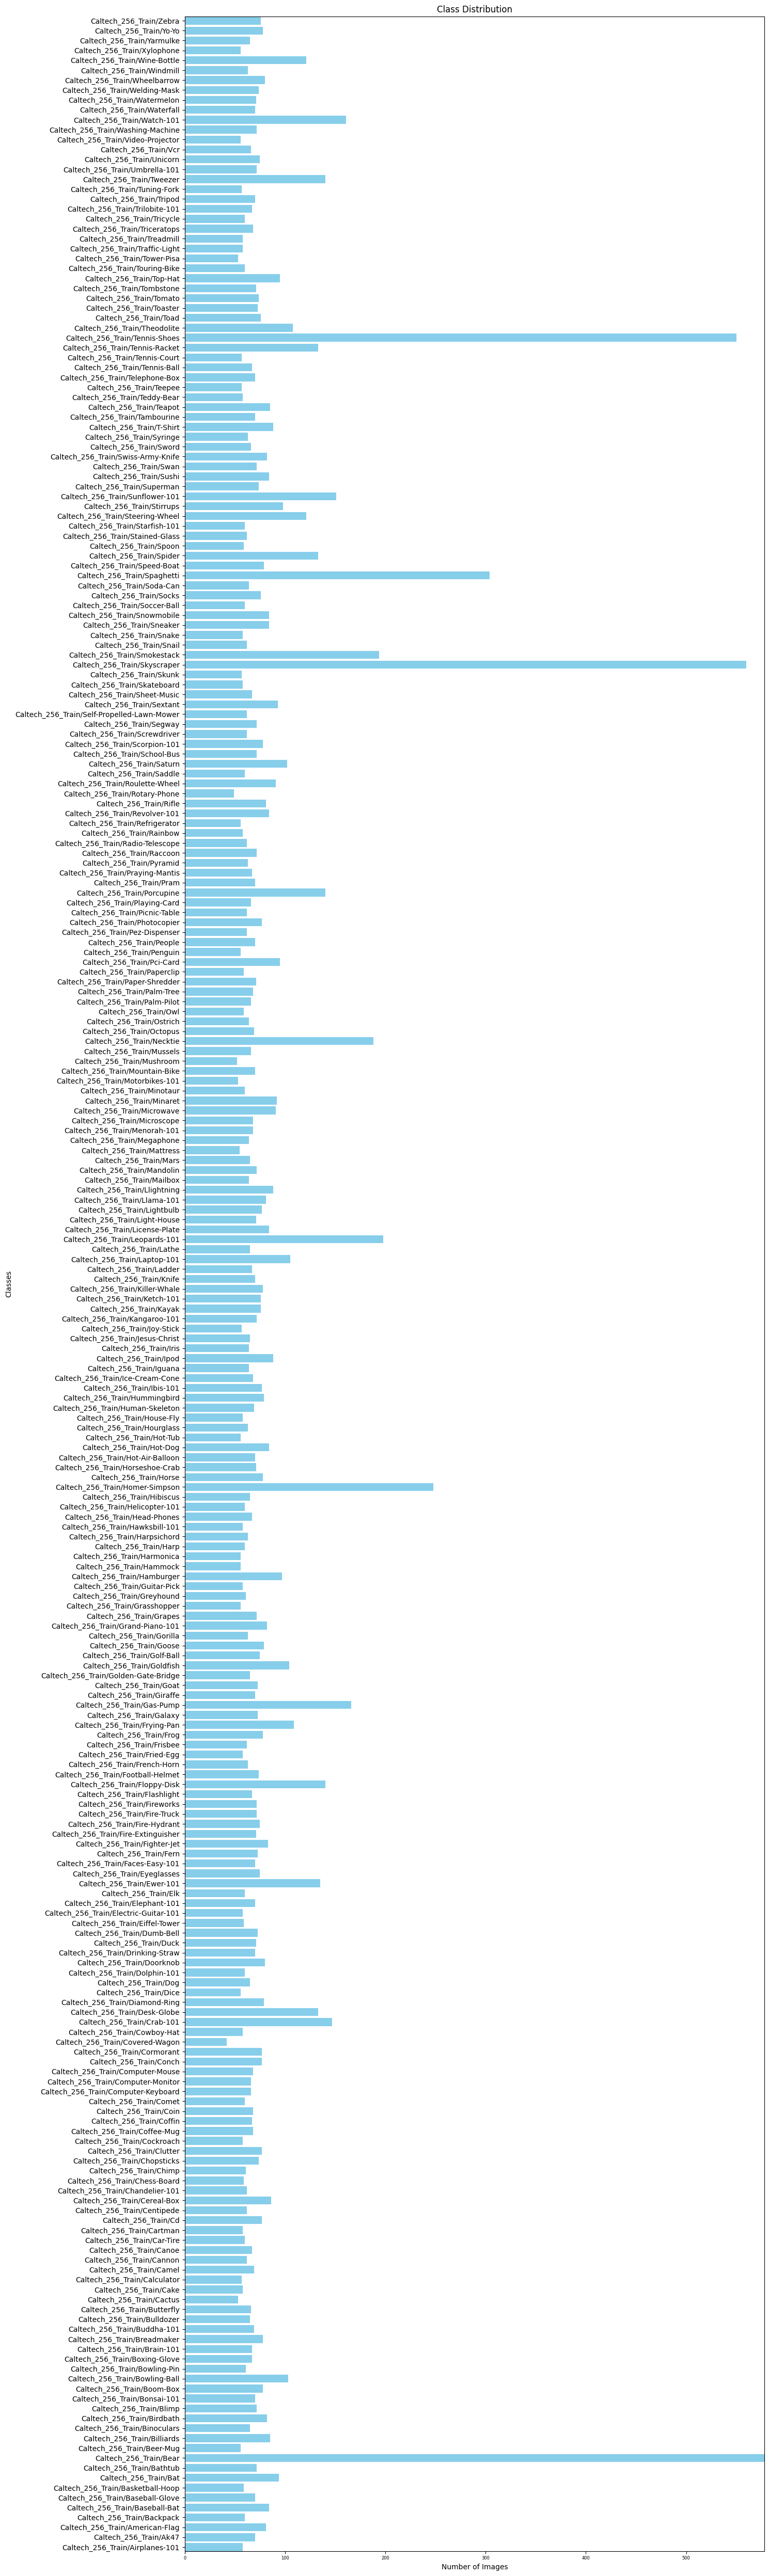

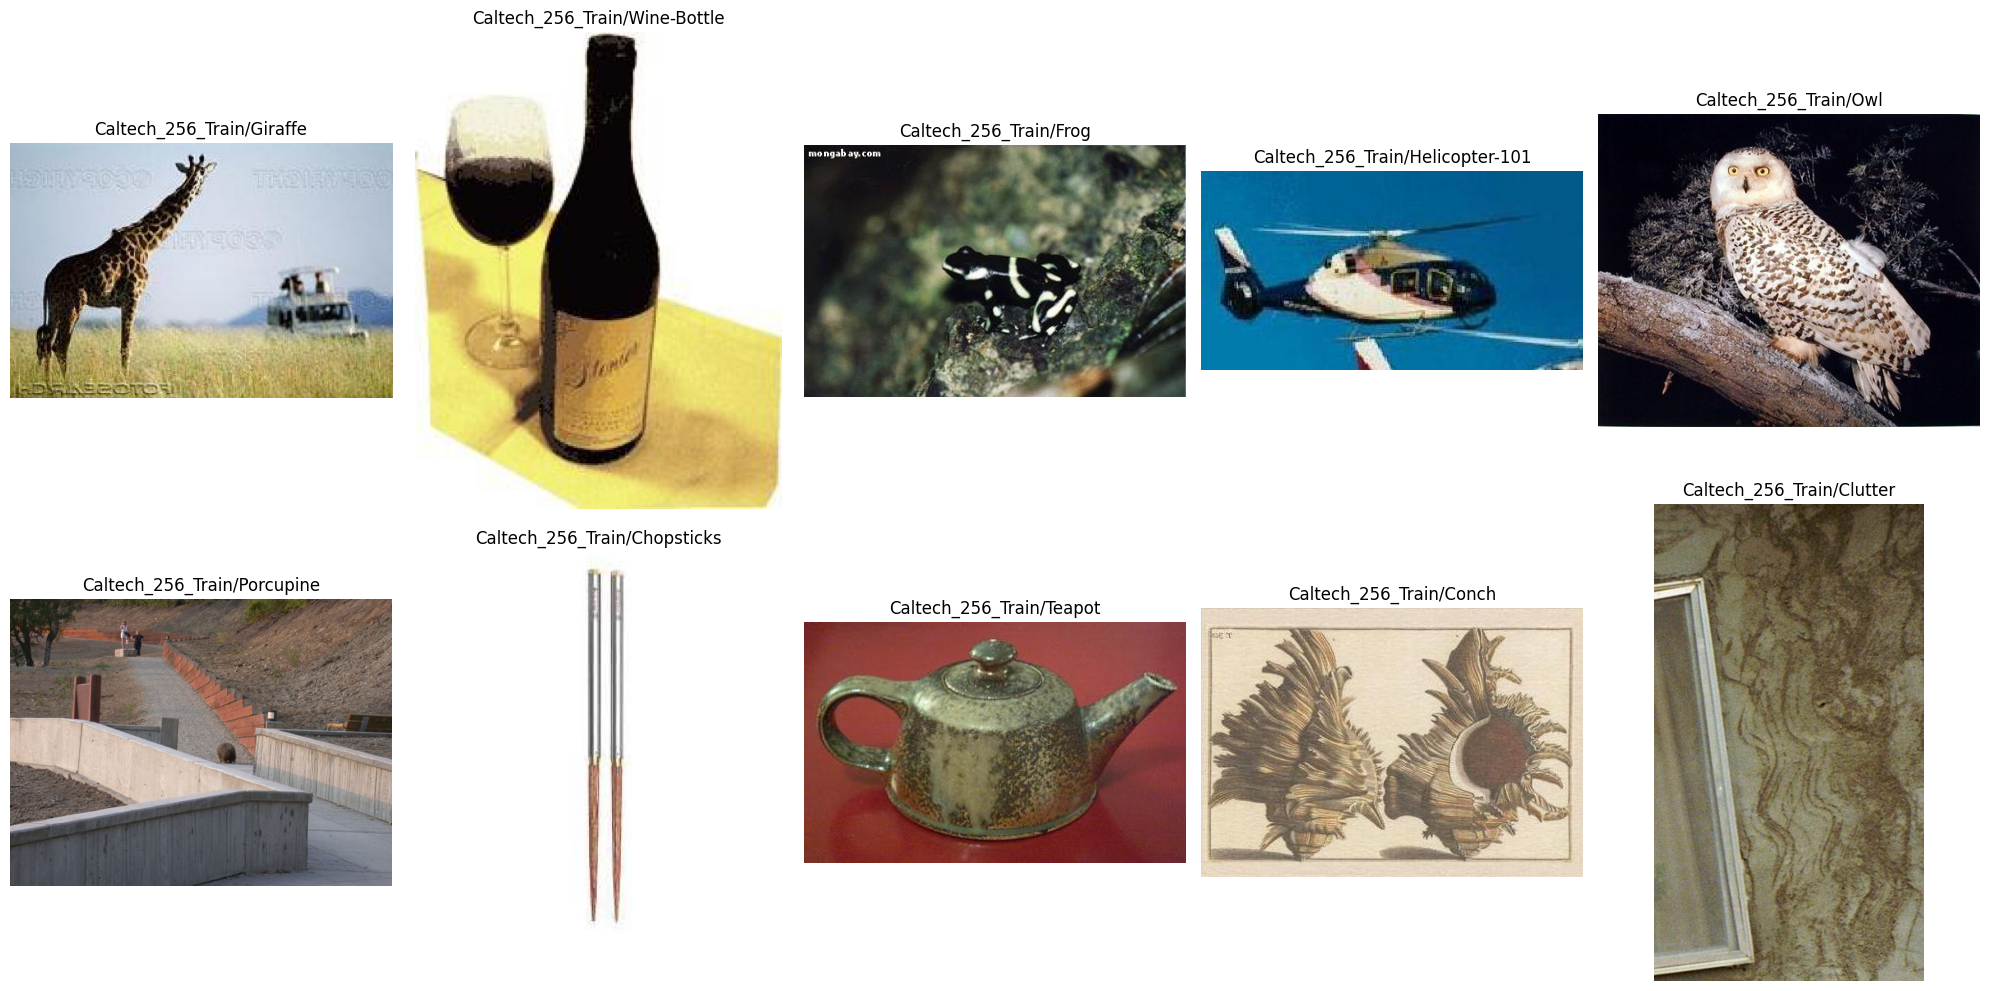

In [ ]:
#1. Bar chart for class distribution
#plt.figure(figsize=(15, 50))
fig, ax = plt.subplots(1,1,figsize=(15, 50))
ax.barh(sorted(class_counts.keys()), class_counts.values(), color='skyblue')
plt.title("Class Distribution")
plt.xlabel("Number of Images")
plt.xticks(fontsize=6)
plt.ylabel("Classes")
plt.tight_layout()
ax.margins(y=0)
ax.margins(x=0)
plt.show()

print()
print()

#2. Visualize sample images of each class
plt.figure(figsize=(20, 10))
classes = list(class_counts.keys())

for i, cls in enumerate(classes[:min(10, len(classes))]):  # Show max 10 classes
    class_images = [p for p, l in zip(image_paths, image_classes) if l == cls]
    img_path = class_images[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i+1)  # Adjust grid if >10 classes
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Stage 2:** Build and train the CNN model using Keras/Pytorch (5 points)

You can train the CNN model and Pre-trained model and then compare the model performance on the kaggle testset


In [11]:
#1. Load Dataset
root_dir = 'Caltech_256_Train'


#2. Define transfom to convert image to tensor
# 2.1. Define a basic transform to convert images to tensors (no normalization yet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to fixed size
    transforms.ToTensor()           # Convert to tensor and scale to [0, 1]
])

#2.2 Load data and created data loader
batch_size=64

train_dataset = datasets.ImageFolder(root=root_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

#2. Calculate MEAN and STD for image Training dataset
mean = 0.
std = 0.
nb_samples = 0.

for data, _ in tqdm(train_loader):
    batch_samples = data.size(0)        # batch size (64 here)
    data = data.view(batch_samples, data.size(1), -1)  # flatten H and W
    mean += data.mean(2).sum(0)
    std += data.std(2).sum(0)
    nb_samples += batch_samples

mean /= nb_samples
std /= nb_samples

print('Mean:', mean)
print('Std:', std)

100%|██████████| 329/329 [01:36<00:00,  3.43it/s]

Mean: tensor([0.5503, 0.5316, 0.5028])
Std: tensor([0.2353, 0.2345, 0.2373])


In [14]:
#3. Use derived Mean and Std to redefine transform
# Normalize with mean and std
#transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(tuple(mean), tuple(std))])
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize((0.4839, 0.4528, 0.3962), (0.2702, 0.2655, 0.2745))])

In [15]:
# Generate a batches of images and labels
train_images, train_labels = next(iter(train_loader))
train_images.shape, train_labels.shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

In [16]:
# labels Translator
label_names = {v: k for k, v in train_dataset.class_to_idx.items()}
label_names

{0: 'Airplanes-101',
 1: 'Ak47',
 2: 'American-Flag',
 3: 'Backpack',
 4: 'Baseball-Bat',
 5: 'Baseball-Glove',
 6: 'Basketball-Hoop',
 7: 'Bat',
 8: 'Bathtub',
 9: 'Bear',
 10: 'Beer-Mug',
 11: 'Billiards',
 12: 'Binoculars',
 13: 'Birdbath',
 14: 'Blimp',
 15: 'Bonsai-101',
 16: 'Boom-Box',
 17: 'Bowling-Ball',
 18: 'Bowling-Pin',
 19: 'Boxing-Glove',
 20: 'Brain-101',
 21: 'Breadmaker',
 22: 'Buddha-101',
 23: 'Bulldozer',
 24: 'Butterfly',
 25: 'Cactus',
 26: 'Cake',
 27: 'Calculator',
 28: 'Camel',
 29: 'Cannon',
 30: 'Canoe',
 31: 'Car-Tire',
 32: 'Cartman',
 33: 'Cd',
 34: 'Centipede',
 35: 'Cereal-Box',
 36: 'Chandelier-101',
 37: 'Chess-Board',
 38: 'Chimp',
 39: 'Chopsticks',
 40: 'Clutter',
 41: 'Cockroach',
 42: 'Coffee-Mug',
 43: 'Coffin',
 44: 'Coin',
 45: 'Comet',
 46: 'Computer-Keyboard',
 47: 'Computer-Monitor',
 48: 'Computer-Mouse',
 49: 'Conch',
 50: 'Cormorant',
 51: 'Covered-Wagon',
 52: 'Cowboy-Hat',
 53: 'Crab-101',
 54: 'Desk-Globe',
 55: 'Diamond-Ring',
 56: '

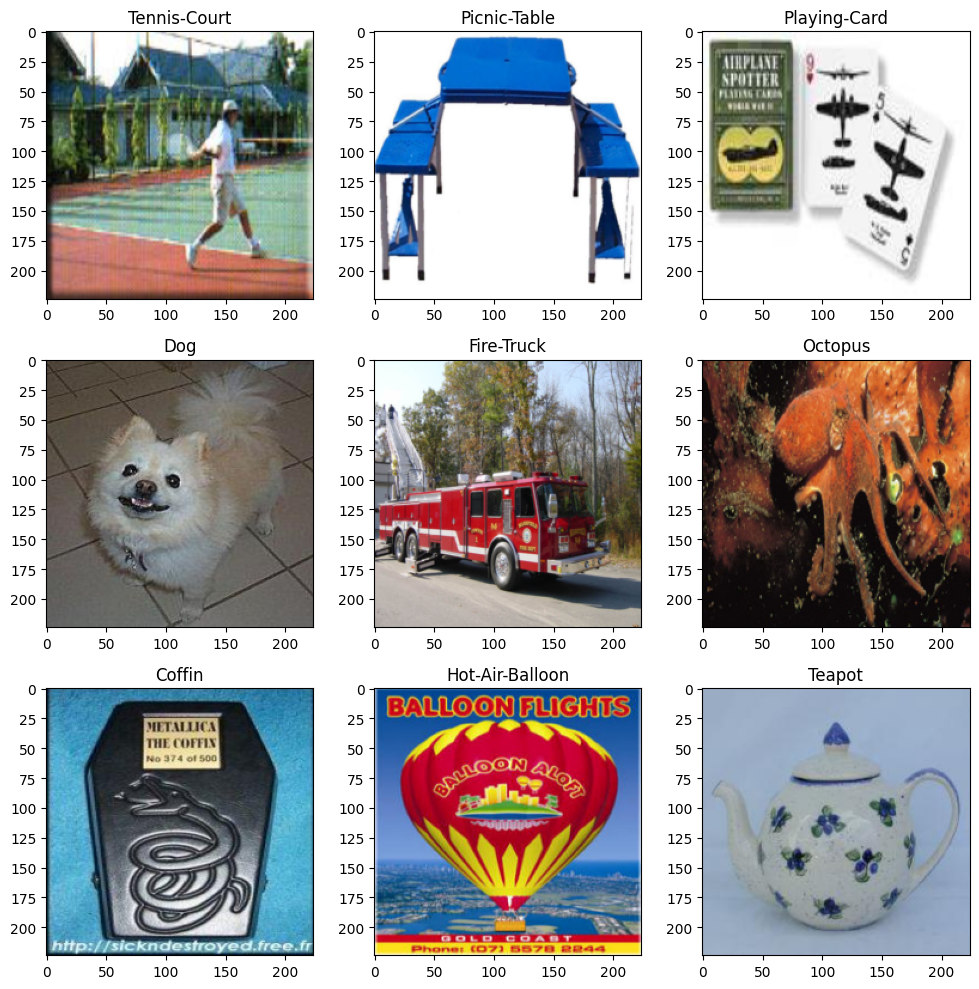

In [17]:
# Create a grid of images along with their corresponding labels
L = 3
W = 3

fig, axes = plt.subplots(L, W, figsize = (10, 10))
axes = axes.reshape(-1)

for i in np.arange(0, L*W):
    axes[i].imshow(train_images[i].permute(1, 2, 0))
    axes[i].set_title(label_names[train_labels[i].item()])
    axes[i].axis('on')

plt.tight_layout()

In [18]:
# No of Categories
len(train_dataset.classes)

256

In [19]:
# Number of training samples
len(train_dataset)

21008

In [20]:
# Size of one training image
train_dataset[0][0].size()

torch.Size([3, 224, 224])

In [21]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([64, 3, 224, 224]) type: torch.FloatTensor
y_train: torch.Size([64]) type: torch.LongTensor


In [22]:
# To test whether GPU instance is present in the system of not.
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

print(device)

!nvidia-smi

cuda
Sat Jul 26 04:55:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

### Transfer learning

Transfer learning consists of taking features learned on one problem, and leveraging them on a new, similar problem.

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task.

The intuition behind transfer learning for image classification is that if a model is trained on a large and general enough dataset, this model will effectively serve as a generic model of the visual world. You can then take advantage of these learned feature maps without having to start from scratch by training a large model on a large dataset.



#### Use the pre-trained models

* Load the pre-trained model
* Train and evaluate the images

In [23]:
#Define ResNet50 Model
model_ft = models.resnet50(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(train_dataset.classes))
model_ft = model_ft.to(device)
print(model_ft)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 55.9MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
#Define Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=0.001)

In [25]:
#Train Model
train_accu = []     # Empty list for saving train accuracy
train_losses = []   # Empty list for saving train losses

def train(epoch):

  print('\nEpoch : %d'%epoch)

  model_ft.train()    # Initiate the model in training mode

  running_loss=0
  correct=0
  total=0

  # Loop through each batch of images in train set
  for data in tqdm(train_loader):

    inputs, labels = data[0].to(device), data[1].to(device)   # Loading the input tensors into CUDA GPU

    # Zero out the gradients from the preivous step
    optimizer.zero_grad()

    # Forward pass (this calls the "forward" function within model_ft)
    outputs = model_ft(inputs)

    # Calculating the loss
    loss = criterion(outputs, labels)

    # Back Propagation for calculaing gradients and adjusting weights
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # Picking the class/label with maximum probability
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()


  train_loss = running_loss/len(train_loader)     # Calculating the mean of training loss
  accu = 100.*correct/total                       # Calculating the accuracy

  train_accu.append(accu)
  train_losses.append(train_loss)
  print('Train Loss: %.3f | Accuracy: %.3f'%(train_loss,accu))

In [26]:
#Train ResNet50
epochs = 15 #20,
for epoch in range(1, epochs+1):
  train(epoch)


Epoch : 1


100%|██████████| 329/329 [03:32<00:00,  1.55it/s]


Train Loss: 4.686 | Accuracy: 11.815

Epoch : 2


100%|██████████| 329/329 [03:38<00:00,  1.50it/s]


Train Loss: 3.277 | Accuracy: 27.447

Epoch : 3


...

Train Loss: 0.178 | Accuracy: 94.578

Epoch : 14


100%|██████████| 329/329 [03:37<00:00,  1.52it/s]


Train Loss: 0.159 | Accuracy: 95.387

Epoch : 15


100%|██████████| 329/329 [03:37<00:00,  1.51it/s]

Train Loss: 0.141 | Accuracy: 96.054


In [27]:
#Save Model
PATH='/content/Oxford-IIIT-ResNet50.pth'
torch.save(model_ft.state_dict(), PATH)

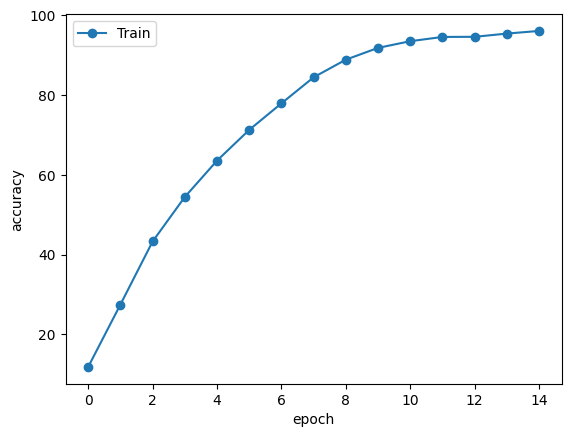

In [28]:
#Plot Accuracy
plt.plot(train_accu,'-o')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['Train'])
plt.show()

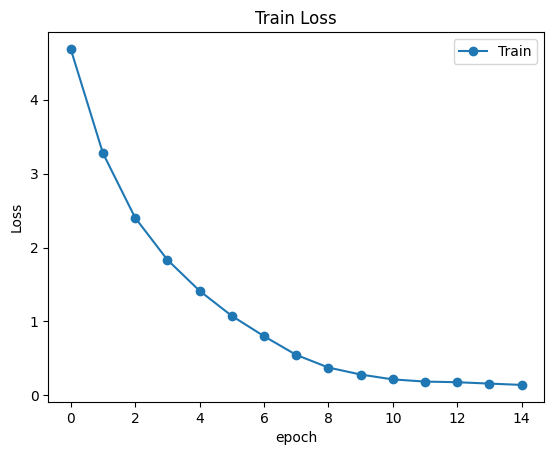

In [29]:
#Plot Training Loss
plt.plot(train_losses,'-o')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend(['Train'])
plt.title('Train Loss')
plt.show()

In [30]:
#Load Model Weights
PATH = '/content/Oxford-IIIT-ResNet50.pth'
model_ft.load_state_dict(torch.load(PATH))

<All keys matched successfully>

###   **Stage 3**: Evaluate the Model and get model predictions on the Kaggle testset (2 Points)









In [31]:
model_ft.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [39]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Define a custom dataset for the test images
class TestImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_files = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
        # Assuming test set doesn't have ground truth labels, we create dummy labels
        self.labels = [0] * len(self.img_files) # Dummy labels

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, os.path.basename(img_path) # Return image, dummy label, and filename

# Load the testset using the custom dataset
test_data_folder = "test"
test_data = TestImageDataset(img_dir=test_data_folder, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1)

FileNotFoundError: Couldn't find any class folder in test.

In [34]:
predictions = []
image_filenames = [] # To store image filenames

# Loop through the test set
with torch.no_grad(): # Disable gradient calculation for inference
    for inputs, _, filenames in tqdm(test_loader): # data now contains image, dummy label, and filename
        inputs = inputs.to(device)

        # Forward pass
        outputs = model_ft(inputs)

        # Get the predicted class index
        _, predicted_idx = torch.max(outputs, 1)

        # Convert predicted index to class name
        predicted_class = label_names[predicted_idx.item()]

        # Storing the predictions and filenames
        predictions.append(predicted_class)
        image_filenames.extend(filenames) # Add filename to list

100%|██████████| 9177/9177 [02:14<00:00, 68.35it/s]


In [35]:
# Since the test set doesn't have ground truth labels, we cannot calculate accuracy directly.
# We will skip this step and proceed to generate the submission file.
print("Skipping accuracy calculation as test set has no ground truth labels.")

Skipping accuracy calculation as test set has no ground truth labels.


In [36]:
results = pd.DataFrame()
results['img_path'] = [test_data_folder + '/' + filename for filename in image_filenames] # Use image filenames
results['label'] = predictions # Store predictions as 'label' for submission

results.sort_values(by='img_path', ignore_index=True,  key=lambda x: x.str.extract('(\d+)').astype(int)[0], inplace=True)

In [37]:
# This step is not applicable as we don't have ground truth labels for the test set.
# We will skip this step.
print("Skipping Correct/Wrong column creation as test set has no ground truth labels.")

Skipping Correct/Wrong column creation as test set has no ground truth labels.


In [38]:
# Generate submission file in the required format (image_filename, label)
results.to_csv("submission_3.csv", index=False)

In [ ]:
# This step is not applicable as we don't have ground truth labels for the test set.
# We will skip this step.
print("Skipping display of wrong predictions as test set has no ground truth labels.")

Skipping display of wrong predictions as test set has no ground truth labels.


In [ ]:
results["Correct/Wrong"].value_counts()

KeyError: 'Correct/Wrong'

In [1]:
#Infrence Test Images
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_class = class_names[pred.item()]
    return predicted_class

In [ ]:
# Run Prediction on all test images
results = []
for filename in os.listdir(test_dir):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_path = os.path.join(test_dir, filename)
        predicted_label = predict_image(img_path)
        results.append({'img_path': filename, 'label': predicted_label})

In [ ]:
#Save Output
# Save to CSV
df = pd.DataFrame(results)
df.to_csv('submission_4.csv', index=False)

### Report Analysis

- Compare the accuracies for the Pre-trained vs CNN models
- What process was followed to tune the hyperparameters?
- Plot the confusion matrix in terms of the misclassifications

In [ ]:
Input Feature Map:
[[1, 2],
 [3, 4]]

In [ ]:
Kernel:
[[w1, w2],
 [w3, w4]]

In [ ]:
Kernel:
[[0.5, 0.2],
 [0.1, 0.8]]

In [ ]:
[[1*0.5, 1*0.2,   0,   0],
 [1*0.1, 1*0.8,   0,   0],
 [    0,     0,   0,   0],
 [    0,     0,   0,   0]]

=
[[0.5, 0.2, 0.0, 0.0],
 [0.1, 0.8, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0]]

In [ ]:
[[0.0, 0.0, 2*0.5, 2*0.2],
 [0.0, 0.0, 2*0.1, 2*0.8],
 [0.0, 0.0,   0.0,   0.0],
 [0.0, 0.0,   0.0,   0.0]]